# Praktikum Data Science
## Nama:Reno Miftahudin Nim: 123240248 Kelas:IF-I

## Clustering: K-Means dan Hierarchical Clustering

**Studi Kasus:** Segmentasi Negara untuk Prioritas Bantuan Internasional
**Dataset:** Country-data.csv (Unsupervised Learning on Country Data, Kaggle)

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

## 2. Load Dataset

Muat dataset Country-data.csv ke dalam DataFrame.

**Tugas:**
- Baca dataset.
- Tampilkan 5 baris pertama.
- Tampilkan informasi umum dataset.

In [2]:
df = pd.read_csv('Country-data.csv')

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Exploratory Data Analysis (EDA)

Lakukan pemeriksaan awal terhadap dataset.

**Minimal lakukan:**
- ukuran dataset;
- tipe data;
- missing value;
- data duplikat;
- statistik deskriptif;
- distribusi fitur numerik (histogram/boxplot).

In [3]:
print("Ukuran dataset:", df.shape)
print("Jumlah data:", df.shape[0])
print("Jumlah fitur:", df.shape[1])

Ukuran dataset: (167, 10)
Jumlah data: 167
Jumlah fitur: 10


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


In [5]:
print("Jumlah missing value setiap kolom:")
print(df.isnull().sum())

Jumlah missing value setiap kolom:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [6]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [7]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


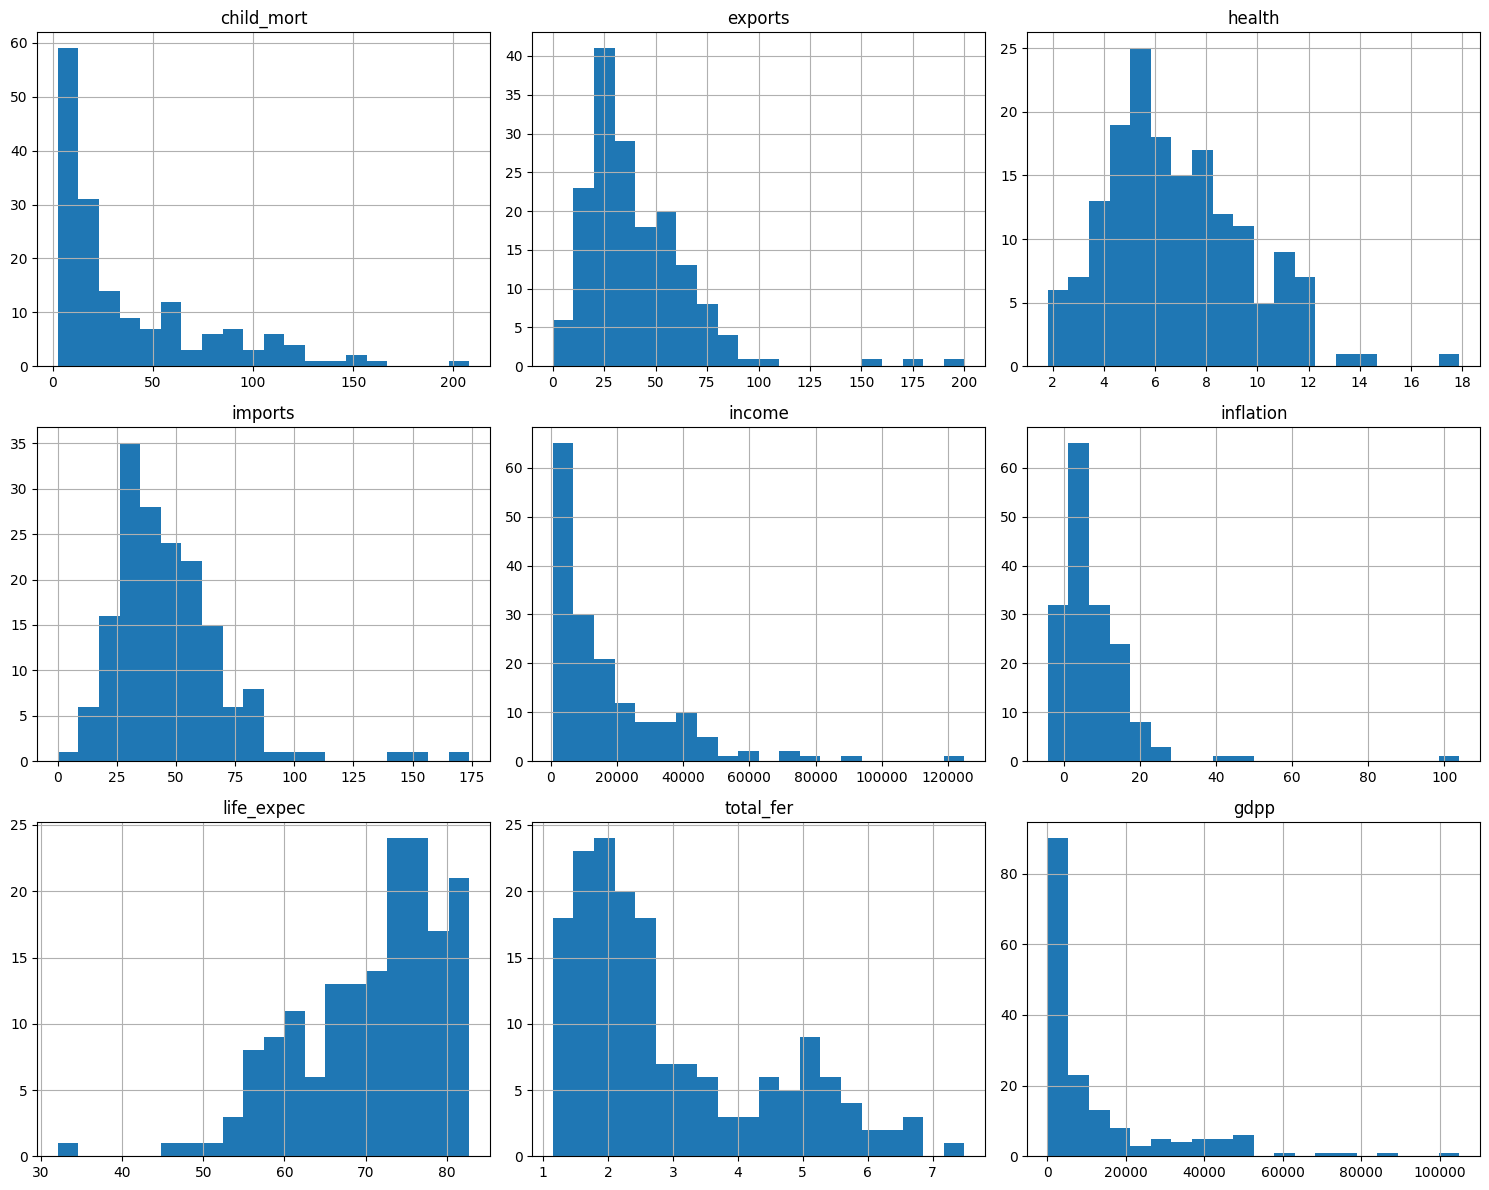

In [25]:
numeric_cols = [
    'child_mort',
    'exports',
    'health',
    'imports',
    'income',
    'inflation',
    'life_expec',
    'total_fer',
    'gdpp'
]

df[numeric_cols].hist(figsize=(15, 12), bins=20)

plt.tight_layout()
plt.show()

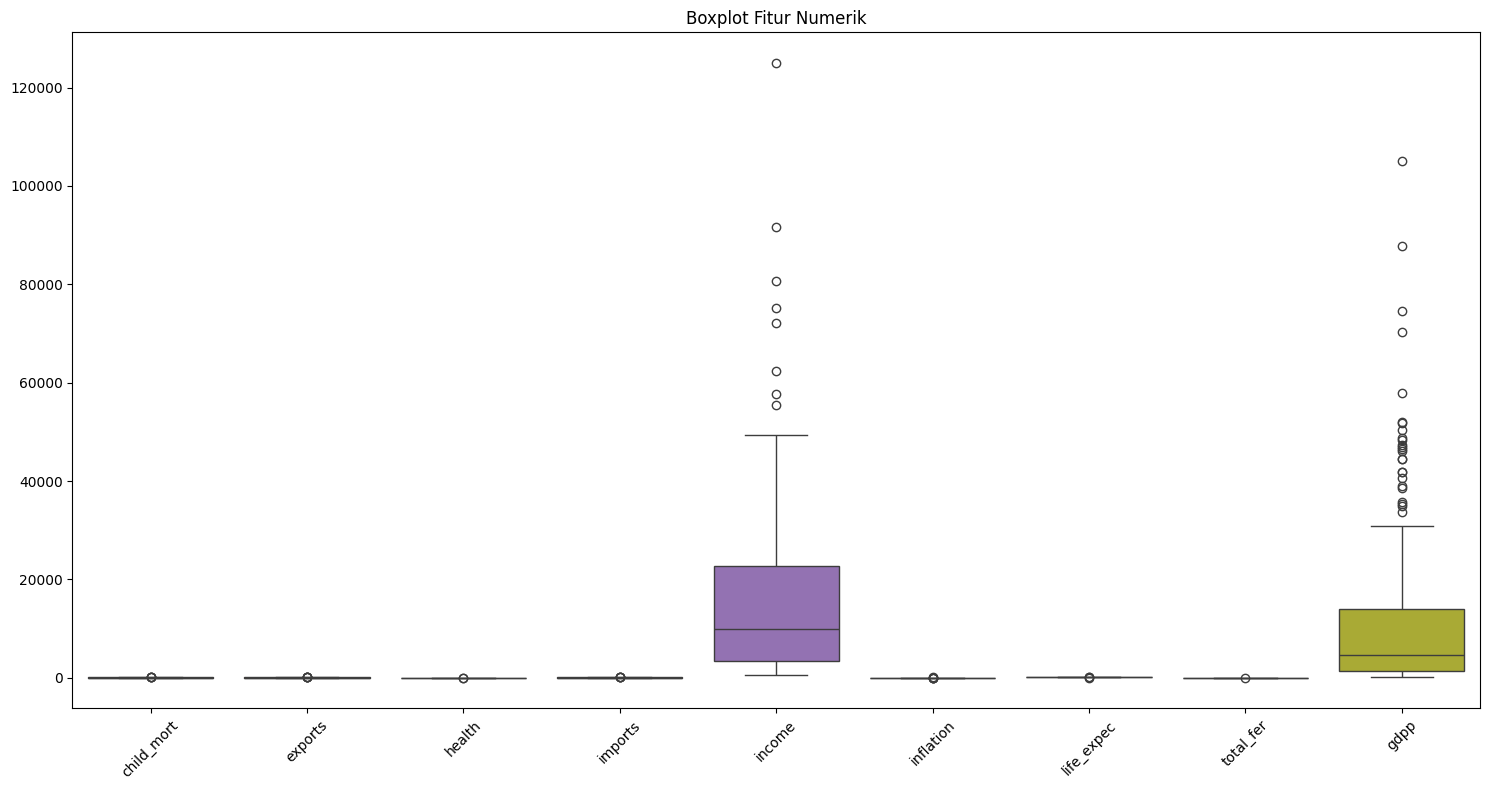

In [26]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45)
plt.title("Boxplot Fitur Numerik")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Lakukan preprocessing sesuai kondisi dataset.

**Periksa dan tangani jika diperlukan:**
- missing value;
- data duplikat/redundan;
- outlier;
- data yang tidak sesuai.

Fitur numerik yang tersedia: child_mort, exports, health, imports, income, inflation, life_expec, total_fer, gdpp.

In [27]:
print("Missing value setiap fitur:")
print(df[numeric_cols].isnull().sum())

Missing value setiap fitur:
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [28]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [29]:
print("Jumlah nilai negatif:")
print((df[numeric_cols] < 0).sum())

Jumlah nilai negatif:
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     8
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [30]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = (
    (df[numeric_cols] < lower_bound) |
    (df[numeric_cols] > upper_bound)
).sum()

print("Jumlah outlier setiap fitur:")
print(outlier_count)

Jumlah outlier setiap fitur:
child_mort     4
exports        5
health         2
imports        4
income         8
inflation      5
life_expec     3
total_fer      1
gdpp          25
dtype: int64


### Penanganan Outlier

Berdasarkan pemeriksaan menggunakan metode IQR, terdapat beberapa nilai yang terdeteksi sebagai outlier. Nilai tersebut tetap dipertahankan karena belum terdapat indikasi bahwa nilai tersebut merupakan kesalahan data. Nilai ekstrem dapat merepresentasikan karakteristik nyata suatu negara dan masih relevan untuk proses clustering.

## 5. Feature Selection

Tentukan fitur numerik yang digunakan untuk proses clustering. Jangan gunakan country (nama negara) sebagai fitur clustering.

**Tuliskan alasan singkat pemilihan fitur.**

In [31]:
X = df[numeric_cols].copy()

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Feature Selection

Fitur yang digunakan dalam proses clustering adalah `child_mort`, `exports`, `health`, `imports`, `income`, `inflation`, `life_expec`, `total_fer`, dan `gdpp`. Fitur `country` tidak digunakan karena merupakan identitas/nama negara, bukan karakteristik numerik untuk proses clustering.

## 6. Scaling

Lakukan standardisasi terhadap fitur yang telah dipilih.

> **Penting:** hasil scaling pada bagian ini akan digunakan kembali untuk **K-Means dan Hierarchical Clustering**. Jangan membuat scaling terpisah untuk masing-masing metode.

# A. K-MEANS CLUSTERING
## 7. Menentukan Jumlah Cluster dengan Elbow Method

Gunakan Elbow Method untuk membantu menentukan jumlah cluster yang sesuai.

**Output:**
- grafik Elbow Method;
- kandidat jumlah cluster.

In [ ]:
# TODO: Elbow Method

## 8. Implementasi K-Means

Terapkan K-Means menggunakan jumlah cluster yang dipilih berdasarkan analisis sebelumnya.

**Output:**
- label cluster;
- jumlah anggota setiap cluster.

In [ ]:
# TODO: K-Means

## 9. Evaluasi K-Means dengan Silhouette Score

Hitung Silhouette Score dari hasil K-Means.

**Tuliskan interpretasi singkat terhadap nilai yang diperoleh.**

In [ ]:
# TODO: Silhouette Score K-Means

## 10. Visualisasi Hasil K-Means

Buat visualisasi yang sesuai untuk membantu melihat pembagian cluster. Jika jumlah fitur lebih dari dua, pilih pendekatan visualisasi yang sesuai dengan materi praktikum (misalnya scatter plot 2 fitur paling relevan).

In [ ]:
# TODO: Visualisasi K-Means

## 11. Profil dan Interpretasi Cluster K-Means

Hitung nilai rata-rata fitur pada setiap cluster.

**Buat tabel profil cluster dan berikan deskripsi singkat karakteristik masing-masing cluster.**

In [ ]:
# TODO: Profil cluster K-Means

### Pertanyaan Analisis K-Means
**1.** Berdasarkan Elbow Method dan Silhouette Score, berapa jumlah cluster yang digunakan? Jelaskan dasar pemilihannya.

**2.** Bagaimana karakteristik utama dari setiap cluster?

Tulis jawaban di sini.

# B. HIERARCHICAL CLUSTERING
Gunakan **dataset dan hasil preprocessing/scaling yang sama** seperti pada K-Means.

## 12. Agglomerative Clustering dengan Beberapa Linkage

Coba beberapa linkage yang telah dipelajari:
- Ward
- Average
- Complete
- Single

Gunakan jumlah cluster yang sama terlebih dahulu untuk melakukan perbandingan yang adil.

In [ ]:
# TODO: Agglomerative Clustering untuk beberapa linkage

## 13. Perbandingan Silhouette Score

Hitung dan tampilkan Silhouette Score untuk:
- Ward
- Average
- Complete
- Single

Buat tabel perbandingan agar hasil mudah dibaca.

In [ ]:
# TODO: Hitung dan bandingkan Silhouette Score

## 14. Dendrogram – Ward

Buat dendrogram menggunakan linkage **Ward**.

Gunakan dendrogram untuk menentukan jumlah cluster yang wajar berdasarkan struktur penggabungan cluster.

In [ ]:
# TODO: Dendrogram Ward

## 15. Menentukan Jumlah Cluster dari Dendrogram

Tuliskan:
- ketinggian pemotongan yang digunakan (jika digunakan);
- jumlah cluster yang diperoleh;
- alasan pemilihan jumlah cluster.

In [ ]:
# TODO: Jika diperlukan, lakukan analisis pemotongan dendrogram

## 16. Heatmap Cluster

Buat heatmap fitur yang telah distandarisasi dan diurutkan berdasarkan label cluster.

Gunakan heatmap untuk membantu melihat fitur yang membedakan karakteristik antar-cluster.

In [ ]:
# TODO: Heatmap

## 17. Profil dan Interpretasi Cluster Hierarchical

Buat tabel profil cluster berdasarkan nilai rata-rata fitur.

Jelaskan karakteristik masing-masing cluster.

In [ ]:
# TODO: Profil cluster Hierarchical

### Pertanyaan Analisis Hierarchical
**1.** Linkage mana yang menghasilkan Silhouette Score paling tinggi? Jelaskan apa yang dapat ditunjukkan oleh hasil tersebut.

**2.** Berdasarkan dendrogram Ward, berapa jumlah cluster yang menurutmu paling wajar? Jelaskan dasar pemilihannya.

Tulis jawaban di sini.

# C. PERBANDINGAN K-MEANS DAN HIERARCHICAL

Kedua algoritma diterapkan pada dataset dan hasil preprocessing yang sama.

## 18. Perbandingan Hasil

Bandingkan hasil K-Means dan Hierarchical berdasarkan jumlah cluster, pembagian data, atau karakteristik cluster yang terbentuk.

In [ ]:
# TODO: Buat tabel/ringkasan perbandingan jika diperlukan

### Pertanyaan Analisis Perbandingan
**1.** Apa perbedaan utama hasil K-Means dan Hierarchical Clustering pada dataset yang sama? Jelaskan berdasarkan jumlah cluster, pembagian data, atau karakteristik cluster yang terbentuk.

Tulis jawaban di sini.

# D. KESIMPULAN

Tuliskan kesimpulan singkat berdasarkan:
1. hasil K-Means;
2. hasil Hierarchical Clustering;
3. perbedaan hasil kedua metode.

Tulis kesimpulan di sini.